In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep, Sequence, RFPowerSweep, RFPowerSweepVolLinear, \
                                            RigolAWGSweep, RFPowerSweepAWG, RFPowerSweepVolLinTipSwitched, \
                                            RFPowerSweepOnOff, RFPowerSweepOnOffTipOff, TipVoltageSweepDifferential, \
                                            RFPowerSweepOnOffDifferential, RFPowerConstSweepDifferential, \
                                            RFPowerSweepOnOffDifferentialTipSwitched, RFPowerConstSweepDifferentialTipSwitched
from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_071526')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> ERROR connecting to SiglentSPD3303X_E at TCPIP::192.168.169.101::INSTR: [Errno 104] Connection reset by peer
>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1465714285 Hz and power 0 dBm.


In [3]:
exp.list_devices()

['Agilent', 'DAC', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA', 'Valon']

100%|█████████████████████████████████████████████| 9/9 [00:23<00:00,  2.57s/it]


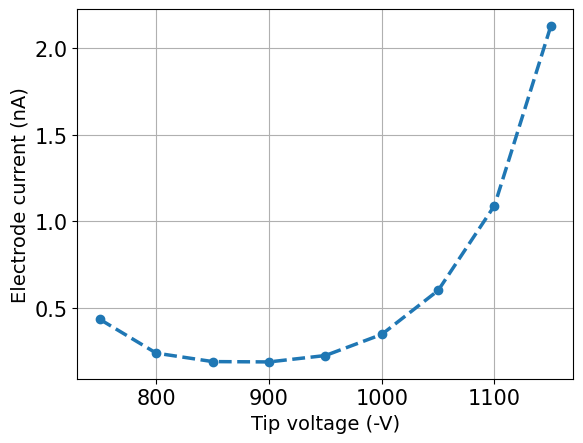

In [27]:
tip_Vsweep = TipVoltageSweepDifferential(saving_dir=exp.saving_dir, 
                                 V_start=750, V_stop=1150, V_step=50, R=200e6, 
                                 N_avg=1, t_PSU_settle=2, t_meas_delay=0.2, 
                                 V_fixed=40, ch_sweep='neg', ch_fixed='pos',
                                 FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)
file = tip_Vsweep.run_save()
plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e9, yerr=np.std(file['all_I'], axis=1)*1e9, fmt='.--', 
            xlabel='Tip voltage (-V)', ylabel='Electrode current (nA)', label=f'Ring bias +600V')

In [192]:
exp.SSA.select_mode('RTSA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(10e3)
exp.SSA.set_freq_center(176.2190e6)
exp.SSA.set_div_scale(1)
exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(100)
exp.SSA.set_ref_level(-65)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [18]:
exp.SSA.select_mode('SA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(1e6)
exp.SSA.set_freq_center(176.310e6)
exp.SSA.set_div_scale(3)
exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(1e3)
exp.SSA.set_VBW(1e3)
exp.SSA.set_ref_level(-58)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [7]:
RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=0, V_off=0, V_pos=0,
                                 t_load=20, t_data=0.1, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
exp.DAC.set_multipoles(Ex=0.5, U2=-0.7)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.5, U2=-0.7, background=False)
file = RF_sweep.run_save()
beep_jupyter()

Traceback (most recent call last):
  File "/home/electron/miniconda3/envs/artiq/bin/artiq_client", line 10, in <module>
    from importlib.metadata import distribution
  File "/home/electron/miniconda3/envs/artiq/lib/python3.8/importlib/metadata.py", line 9, in <module>
    import zipfile
  File "/home/electron/miniconda3/envs/artiq/lib/python3.8/zipfile.py", line 13, in <module>
    import shutil
  File "/home/electron/miniconda3/envs/artiq/lib/python3.8/shutil.py", line 41, in <module>
    from grp import getgrnam
  File "<frozen importlib._bootstrap>", line 991, in _find_and_load
  File "<frozen importlib._bootstrap>", line 971, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 914, in _find_spec
KeyboardInterrupt
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x72f87ad1bac0>>
Traceback (most recent call last):
  File "/home/electron/miniconda3/envs/artiq/lib/python3.8/site-packages/i

KeyboardInterrupt: 

In [9]:
for Ex in [-0.1, 0, 0.3, 0.5, 0.7]:
    RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1100, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.1, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    time.sleep(5)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    file = RF_sweep.run_save()
# for U2 in [-1, -0.7, -0.4, 1]:
#     exp.DAC.set_multipoles(Ex=0.3, U2=U2)
#     time.sleep(5)
#     RF_sweep.set_parameters(Ex=0.3, U2=U2, background=False)
#     file = RF_sweep.run_save()
beep_jupyter()

RID: 10112
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10113
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10114
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10115
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.22s/it]


RID: 10116
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


In [11]:
for U2 in [-0.4, 1, -1, -0.7]:
    RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1100, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.1, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
    exp.DAC.set_multipoles(Ex=0.5, U2=U2)
    time.sleep(5)
    RF_sweep.set_parameters(Ex=0.5, U2=U2, background=False)
    file = RF_sweep.run_save()
# for U2 in [-1, -0.7, -0.4, 1]:
#     exp.DAC.set_multipoles(Ex=0.3, U2=U2)
#     time.sleep(5)
#     RF_sweep.set_parameters(Ex=0.3, U2=U2, background=False)
#     file = RF_sweep.run_save()
beep_jupyter()

RID: 10121
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.22s/it]


RID: 10122
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10123
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


RID: 10124
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:36<00:00, 25.23s/it]


In [3]:
class RFPowerSweepRevivalDifferential(RFPowerSweepOnOffDifferentialTipSwitched):
    def __init__(self, name='RFPowerSweepRevivalDifferential', saving_dir=None,
                 P_load=10, P_detect=5, V_on=800, V_off=500, V_pos=600,
                 t_load=10, t_data=1, t_rest=1,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW=30e3, N_avg=32,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         P_load=P_load, P_detect=P_detect, 
                         t_load=t_load, t_data=t_data, t_rest=t_rest,
                         N_avg=N_avg, V_on=V_on, V_off=V_off, V_pos=V_pos,
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         display_progress=display_progress,
                         **kwargs)
    
    def run(self):
        self.SSA.select_mode('SA')
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up_ch('pos', self.V_pos)
        self.FEtip_PSU.ramp_up(self.V_off)
        
        self.SSA.clear_averaging()
        data = self.SSA.get_full_trace()
        self.SSA.set_div_scale(5) 
        self.SSA.set_ref_level(max(data)+25)
        P_seq = [self.P_detect, self.P_load, self.P_detect]
        all_meas = []
        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):
            loc_data = []
            self.FEtip_PSU.set_voltage(self.V_on)
            self.Valon.output_on() 
            self.Valon.set_power(self.P_load)
            time.sleep(self.t_load)
            for P in P_seq:
                self.SSA.clear_averaging() 
                self.Valon.set_power(P)
                data = self.SSA.get_full_trace()
                loc_data.extend(data)
            all_meas.append(loc_data)
            
            self.Valon.output_off()
            time.sleep(self.t_rest)

        self.FEtip_PSU.ramp_down(0)
        self.FEtip_PSU.ramp_down_ch('pos', 0)
        self.Valon.output_off()
        self.SSA.clear_averaging()

        return {'all_meas': np.array(all_meas)}

In [22]:
class RFPowerSweepDifferentialNAcquisition(RFPowerSweepRevivalDifferential):
    def __init__(self, name='RFPowerSweepDifferentialNAcquisition', saving_dir=None,
                 P_load=10, P_detect=5, V_on=800, V_off=500, V_pos=600,
                 t_load=10, t_data=1, t_rest=1,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW=30e3, N_avg=32,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         P_load=P_load, P_detect=P_detect, 
                         t_load=t_load, t_data=t_data, t_rest=t_rest,
                         N_avg=N_avg, V_on=V_on, V_off=V_off, V_pos=V_pos,
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         display_progress=display_progress,
                         **kwargs)
    
    def run(self):
        self.SSA.select_mode('SA')
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, 0.1)
        self.FEtip_PSU.ramp_up_ch('pos', self.V_pos)
        self.FEtip_PSU.ramp_up(self.V_off)
        
        self.SSA.clear_averaging()
        data = self.SSA.get_full_trace()
        self.SSA.set_div_scale(5) 
        self.SSA.set_ref_level(max(data)+25)
        N_data = int(self.t_data/0.1)
        all_meas = []
        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):
            loc_data = []
            self.FEtip_PSU.set_voltage(self.V_on)
            self.Valon.output_on() 
            self.Valon.set_power(self.P_load)
            time.sleep(self.t_load)
            self.SSA.clear_averaging() 
            self.Valon.set_power(self.P_detect)
            for _ in range(N_data):
                data = self.SSA.get_full_trace()
                loc_data.extend(data)
            all_meas.append(loc_data)
            
            self.Valon.output_off()
            time.sleep(self.t_rest)

        self.FEtip_PSU.ramp_down(0)
        self.FEtip_PSU.ramp_down_ch('pos', 0)
        self.Valon.output_off()
        self.SSA.clear_averaging()

        return {'all_meas': np.array(all_meas)}

In [14]:
RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1125, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.2, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=10e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=False)
file = RF_sweep.run_save()

RID: 10133
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:39<00:00, 25.32s/it]


In [12]:
RF_sweep = RFPowerSweepRevivalDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12, P_detect=5, V_on=1125, V_off=950, V_pos=40,
                                 t_load=20, t_data=0.2, t_rest=5,
                                 SSA_freq_center=176.31e6, SSA_freq_span=0,
                                 SSA_RBW=10e3, N_avg=30,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)
exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=False)
file = RF_sweep.run_save()

RID: 10132
voltages loaded


100%|███████████████████████████████████████████| 30/30 [12:57<00:00, 25.90s/it]


In [28]:
import random
all_P = [4,4.5,4.8,5,5.2,5.5,6]
random.shuffle(all_P)
print(all_P)
for P_detect in all_P:
    RF_sweep = RFPowerSweepDifferentialNAcquisition(saving_dir=exp.saving_dir, 
                                     P_load=12, P_detect=P_detect, V_on=1150, V_off=950, V_pos=40,
                                     t_load=20, t_data=1, t_rest=5,
                                     SSA_freq_center=176.31e6, SSA_freq_span=0,
                                     SSA_RBW=10e3, N_avg=30,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)
    exp.DAC.set_multipoles(Ex=0.25, U2=-0.4)
    time.sleep(5)
    RF_sweep.set_parameters(Ex=0.25, U2=-0.4, background=False)
    file = RF_sweep.run_save()

[4.5, 5, 4, 4.8, 5.5, 6, 5.2]
RID: 10140
voltages loaded


100%|███████████████████████████████████████████| 30/30 [13:25<00:00, 26.85s/it]


RID: 10141
voltages loaded


100%|███████████████████████████████████████████| 30/30 [13:25<00:00, 26.85s/it]


RID: 10142
voltages loaded


...

100%|███████████████████████████████████████████| 30/30 [13:25<00:00, 26.85s/it]


RID: 10145
voltages loaded


100%|███████████████████████████████████████████| 30/30 [13:25<00:00, 26.85s/it]


RID: 10146
voltages loaded


100%|███████████████████████████████████████████| 30/30 [13:25<00:00, 26.85s/it]


In [26]:
beep_jupyter()

In [9]:
exp.DAC.set_multipoles(Ex=0.5, U2=-0.7)
time.sleep(5)
RF_sweep.set_parameters(Ex=0.5, U2=-0.7, background=False)
file = RF_sweep.run_save()

RID: 10058
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.13s/it]


In [4]:
RF_sweep = RFPowerConstSweepDifferential(
    saving_dir=exp.saving_dir,
    P_valon_hold=0,
    valon_settle=2, loading_time=0, measurement_time=30,
    P_min_dBm=12, P_max_dBm=5, steps=2,  
    V_on=1100, V_off=950, V_pos=40,
    SSA_freq_center=176.31e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)
for Ex in [-0.1, 0, 0.3, 0.5, 0.7, 1.5, 3]:
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.7)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.7, background=False)
    file = RF_sweep.run_save()

for U2 in [-1, -0.7, -0.4, 1]:
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
    
beep_jupyter()


RID: 10098
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10099
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.05s/it]


RID: 10100
voltages loaded


...

>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10107
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.08s/it]


RID: 10108
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.14s/it]


In [110]:
exp.FEtip_PSU.ramp_down_ch('pos', 0)

In [109]:
for U2 in [-1, -0.9, -0.8, -0.7]:
    RF_sweep = RFPowerConstSweepTipSwitched(
        saving_dir=exp.saving_dir,
        P_valon_hold=5,
        valon_settle=2, loading_time=0, measurement_time=30,
        P_min_dBm=12.45, P_max_dBm=7.12, steps=2,  
        V_on=850, V_off=500, V_pos=600,
        SSA_freq_center=176.2190e6, SSA_freq_span=0,
        SSA_RBW=1e3, SSA_SWT=0.1,
        Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
        N_inner=1, N_outer=1, 
        display_progress='Pscan'
    )
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
beep_jupyter()


RID: 10015
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.07s/it]


RID: 10016
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.06s/it]


RID: 10017
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10018
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.11s/it]


In [111]:
exp.Valon.output_off()